## IMPORT THƯ VIỆN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


## LOAD DATA

In [9]:
df = pd.read_csv('VCB_final.csv', parse_dates=['DATE'], dayfirst=True)
print("=== THÔNG TIN DỮ LIỆU ===")
df.info()
print("\n=== MÔ TẢ THỐNG KÊ ===")
df.describe()

=== THÔNG TIN DỮ LIỆU ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802 entries, 0 to 801
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    802 non-null    datetime64[ns]
 1   OPEN    802 non-null    float64       
 2   HIGH    802 non-null    float64       
 3   LOW     802 non-null    float64       
 4   CLOSE   802 non-null    float64       
 5   VOLUME  802 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 37.7 KB

=== MÔ TẢ THỐNG KÊ ===


,DATE,OPEN,HIGH,LOW,CLOSE,VOLUME
count,802,802.000000,802.000000,802.000000,802.000000,8.020000e+02
mean,2022-08-14 04:59:51.022444032,72943.407581,73778.336384,72078.341870,72971.484264,1.434721e+06
min,2021-01-04 00:00:00,53344.620000,55292.130000,52497.880000,52497.880000,2.578000e+05
25%,2021-10-25 06:00:00,64832.680000,65285.635000,63849.380000,64701.580000,8.947758e+05
50%,2022-08-13 12:00:00,69009.310000,69856.050000,68175.930000,69009.310000,1.201300e+06
75%,2023-06-05 18:00:00,80900.000000,81417.292500,80250.000000,81050.000000,1.713150e+06
max,2024-03-22 00:00:00,98500.000000,100500.000000,97300.000000,97400.000000,2.885420e+07
std,NaN,10095.650939,10085.466903,10133.001472,10145.196413,1.329982e+06


In [ ]:
print("\n=== CÁC CỘT TRONG DỮ LIỆU ===")
print(df.columns.tolist())

print("\nĐộ dài của tập dữ liệu:", len(df))


print("\n=== KÍCH THƯỚC CỦA TẬP DỮ LIỆU ===")
print("Số hàng:", df.shape[0])
print("Số cột:", df.shape[1])




=== CÁC CỘT TRONG DỮ LIỆU ===
['DATE', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']

Độ dài của tập dữ liệu: 802

=== KÍCH THƯỚC CỦA TẬP DỮ LIỆU ===
Số hàng: 802
Số cột: 6


## TIỀN XỬ LÝ DỮ LIỆU

In [ ]:

print("\n=== SỐ LƯỢNG NULL ===")
print(df.isnull().sum())


=== SỐ LƯỢNG NULL ===
DATE      0
OPEN      0
HIGH      0
LOW       0
CLOSE     0
VOLUME    0
dtype: int64


In [ ]:

for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

In [ ]:

def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    df[col] = cap_outliers(df[col])

In [ ]:

df.sort_values('DATE', inplace=True)
df['Return_1d'] = df['CLOSE'].pct_change()
df['MA_5'] = df['CLOSE'].rolling(5).mean()
df['MA_20'] = df['CLOSE'].rolling(20).mean()
df.dropna(inplace=True)
df

,DATE,OPEN,HIGH,LOW,CLOSE,VOLUME,Return_1d,MA_5,MA_20
782,2021-01-29,56048.48,63521.61,56048.48,60965.01,1359000.0,0.026490,63508.498,66501.0275
781,2021-02-01,62931.62,62931.62,59653.93,59719.49,1331300.0,-0.020430,62013.872,66242.0900
780,2021-02-02,60309.47,63390.50,60309.47,63259.39,1152800.0,0.059275,61436.998,66150.3145
779,2021-02-03,64177.14,64898.24,63324.95,64832.68,1454600.0,0.024870,61633.658,65950.3755
778,2021-02-04,64832.68,64898.24,61554.99,64832.68,967300.0,0.000000,62721.850,65684.8825
...,...,...,...,...,...,...,...,...,...
4,2024-03-18,94300.00,94500.00,92500.00,93000.00,1839300.0,-0.010638,94480.000,93900.0000
3,2024-03-19,92500.00,93500.00,92500.00,92500.00,868500.0,-0.005376,94100.000,93960.0000
2,2024-03-20,92500.00,94100.00,92500.00,93200.00,897700.0,0.007568,93540.000,94060.0000
1,2024-03-21,94000.00,95500.00,94000.00,95200.00,1452700.0,0.021459,93580.000,94345.0000


## TRỰC QUAN HÓA DỮ LIỆU

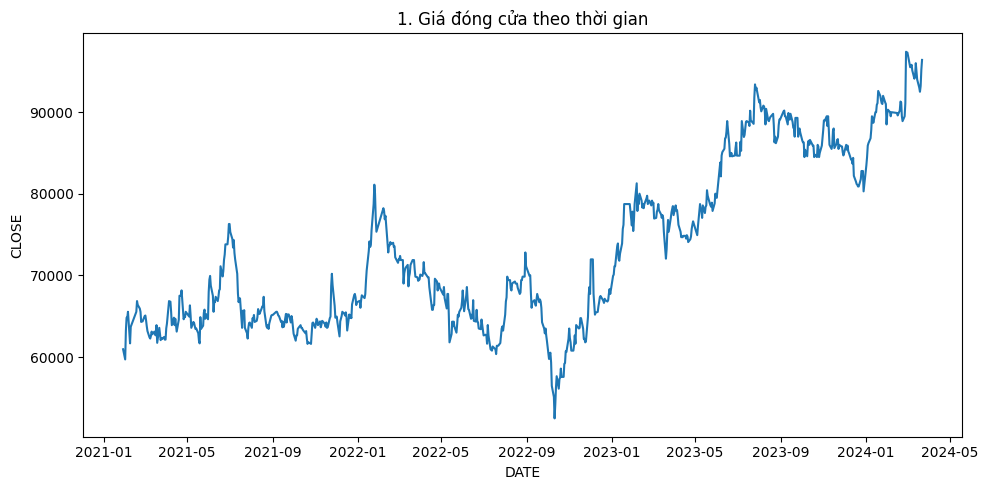

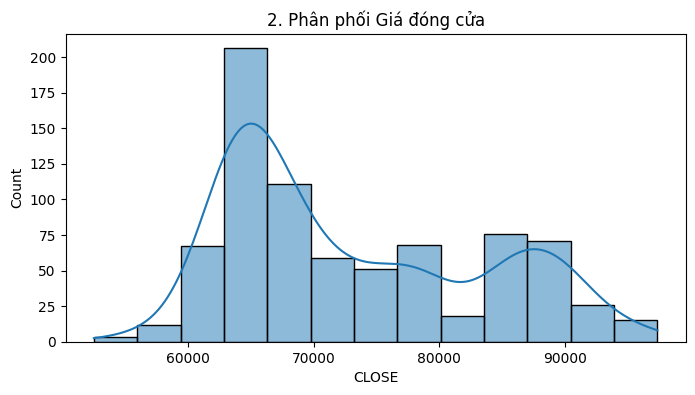

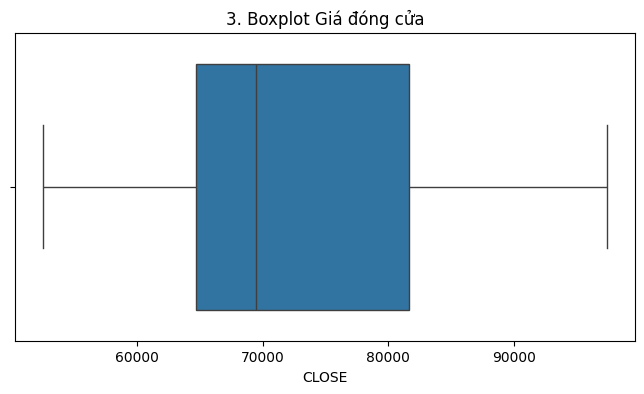

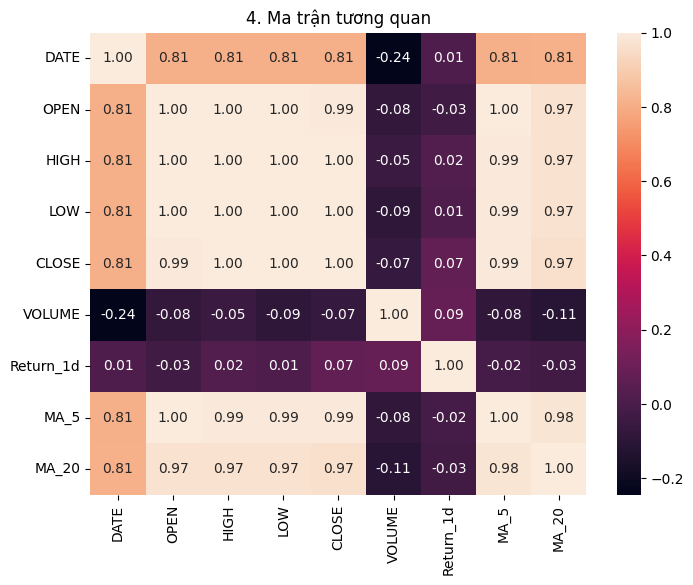

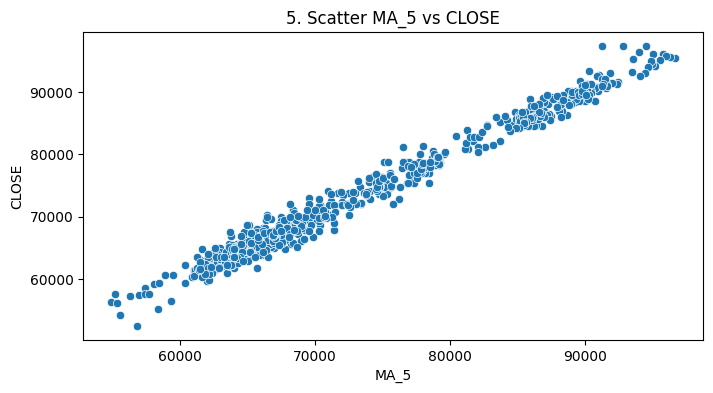

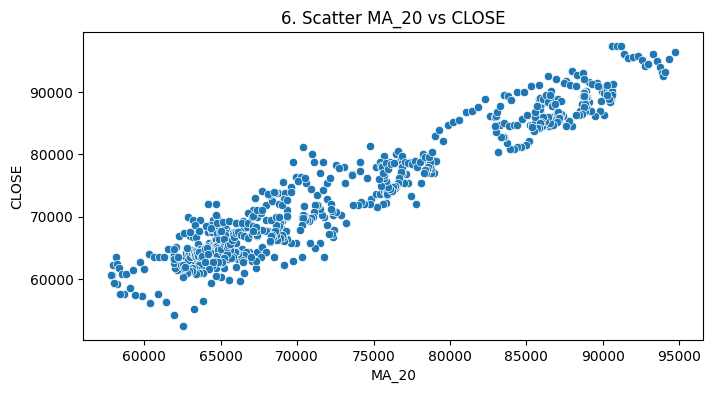

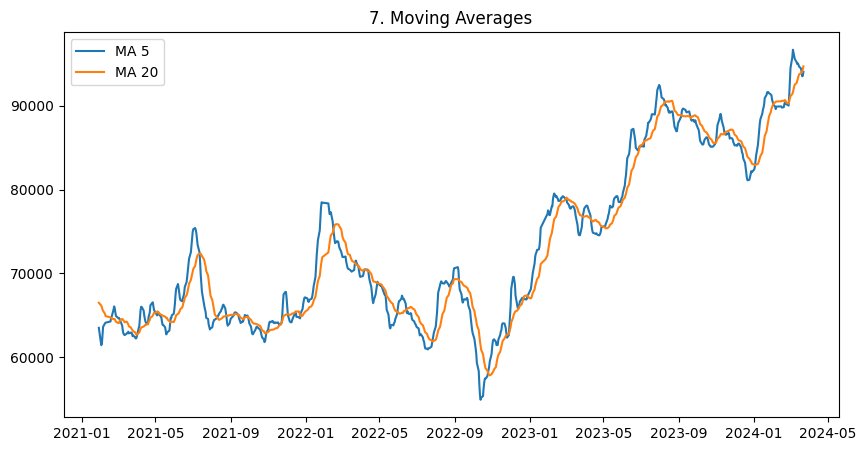

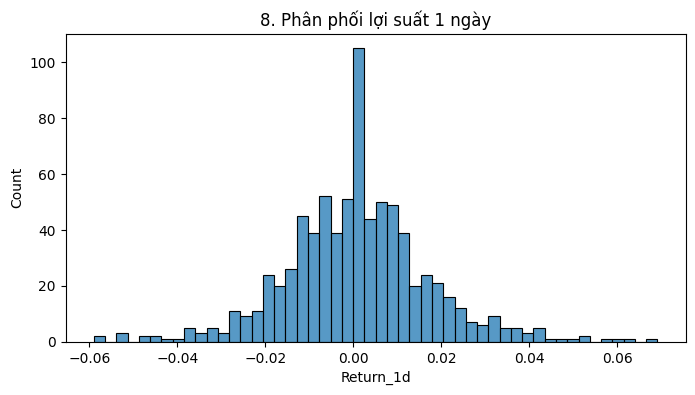

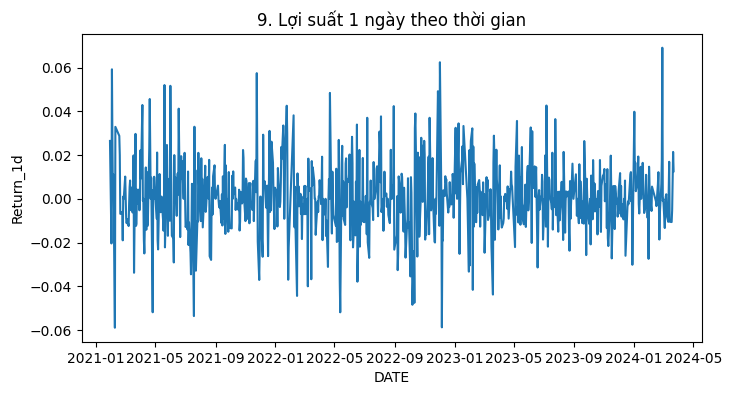

C:\Users\WIN\AppData\Local\Temp\ipykernel_13516\1955741378.py:41: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Return_1d'].dropna(), shade=True)


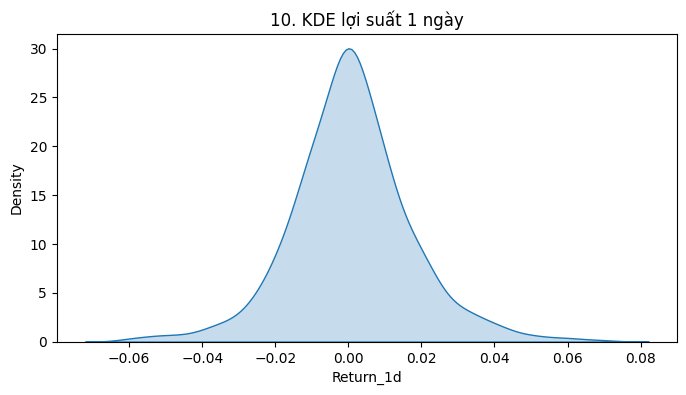

In [16]:
plt.figure(figsize=(10,5))
plt.plot(df['DATE'], df['CLOSE'])
plt.title('1. Giá đóng cửa theo thời gian')
plt.xlabel('DATE'); plt.ylabel('CLOSE')
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['CLOSE'], kde=True)
plt.title('2. Phân phối Giá đóng cửa'); plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df['CLOSE'])
plt.title('3. Boxplot Giá đóng cửa'); plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f')
plt.title('4. Ma trận tương quan'); plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(x='MA_5', y='CLOSE', data=df)
plt.title('5. Scatter MA_5 vs CLOSE'); plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(x='MA_20', y='CLOSE', data=df)
plt.title('6. Scatter MA_20 vs CLOSE'); plt.show()

plt.figure(figsize=(10,5))
plt.plot(df['DATE'], df['MA_5'], label='MA 5')
plt.plot(df['DATE'], df['MA_20'], label='MA 20')
plt.title('7. Moving Averages'); plt.legend(); plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['Return_1d'].dropna(), bins=50)
plt.title('8. Phân phối lợi suất 1 ngày'); plt.show()

plt.figure(figsize=(8,4))
sns.lineplot(x='DATE', y='Return_1d', data=df)
plt.title('9. Lợi suất 1 ngày theo thời gian'); plt.show()

plt.figure(figsize=(8,4))
sns.kdeplot(df['Return_1d'].dropna(), shade=True)
plt.title('10. KDE lợi suất 1 ngày'); plt.show()

## TRAINING MODEL

In [ ]:
feature_cols = ['OPEN','HIGH','LOW','VOLUME','Return_1d','MA_5','MA_20']
X = df[feature_cols]
y = df['CLOSE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  
)

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    
    joblib.dump(model, f'{name}_VCB.pkl')
    
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse  = mean_squared_error(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    results[name] = {'R2': r2, 'RMSE': rmse, 'MSE': mse, 'MAE': mae}
    print(f"{name} -> R2: {r2:.4f}, RMSE: {rmse:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}")


--- Training LinearRegression ---
LinearRegression -> R2: 0.9890, RMSE: 378.0894, MSE: 142951.6213, MAE: 295.9055

--- Training RandomForest ---
RandomForest -> R2: 0.8751, RMSE: 1273.3462, MSE: 1621410.6285, MAE: 843.3338

--- Training GradientBoosting ---
GradientBoosting -> R2: 0.8876, RMSE: 1208.1006, MSE: 1459507.0818, MAE: 798.8518


## SO SÁNH CÁC MODEL


=== KẾT QUẢ SO SÁNH ===
                        R2         RMSE           MSE         MAE
LinearRegression  0.989060   380.211543  1.445608e+05  298.496388
RandomForest      0.877559  1271.998182  1.617979e+06  850.381186
GradientBoosting  0.879693  1260.867219  1.589786e+06  852.763606


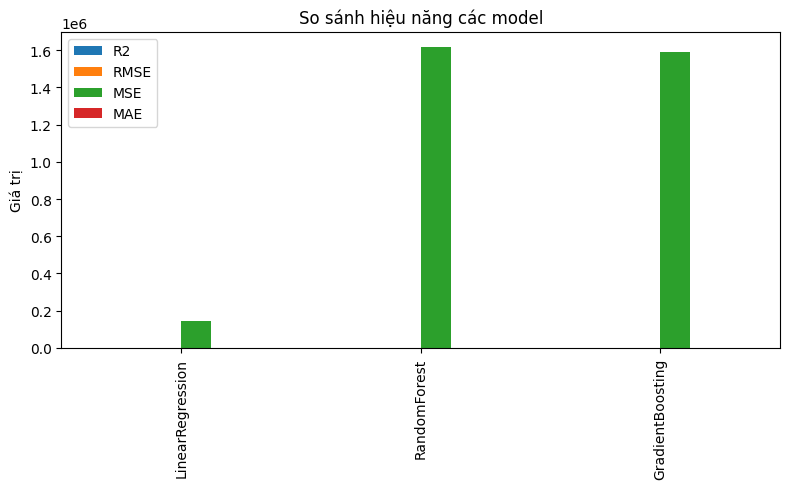

In [20]:
print("\n=== KẾT QUẢ SO SÁNH ===")
df_results = pd.DataFrame(results).T
print(df_results)
df_results.plot.bar(figsize=(8,5))
plt.title('So sánh hiệu năng các model')
plt.ylabel('Giá trị') 
plt.tight_layout()
plt.show()